# Clustering (K-Means)

In [59]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [60]:
df = pd.read_csv('./data/retailmax.csv')

In [61]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [62]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [63]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=25)
clusters = kmeans.fit_predict(scaled_features)

In [64]:
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 2, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       2, 2], dtype=int32)

In [65]:
kmeans = KMeans(n_clusters=10, init='k-means++', max_iter=300, n_init=10, random_state=25)
clusters = kmeans.fit_predict(scaled_features)

In [66]:
clusters

array([5, 4, 5, 4, 5, 4, 5, 4, 8, 4, 8, 4, 8, 4, 5, 4, 5, 4, 8, 4, 5, 4,
       8, 4, 8, 4, 5, 4, 5, 4, 8, 4, 8, 4, 8, 4, 5, 4, 5, 4, 6, 4, 1, 2,
       8, 2, 1, 2, 2, 2, 1, 2, 2, 6, 1, 1, 1, 6, 2, 1, 6, 2, 6, 1, 6, 2,
       1, 6, 2, 2, 6, 1, 6, 6, 6, 2, 1, 1, 2, 1, 6, 1, 6, 1, 2, 1, 1, 2,
       2, 1, 6, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 6, 2, 1, 2, 6, 1, 6, 6,
       6, 2, 1, 2, 2, 2, 6, 1, 1, 1, 2, 1, 1, 3, 9, 3, 1, 3, 0, 3, 0, 3,
       9, 3, 9, 3, 0, 3, 9, 3, 0, 3, 9, 3, 9, 3, 0, 3, 9, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 9, 3, 0, 3, 9, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 7, 3, 0, 3, 7, 3, 0, 3, 7, 3, 7, 3, 7, 3, 7, 3, 7, 3,
       7, 3], dtype=int32)

In [67]:
df["Cluster"] = clusters
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
95,96,Male,24,60,52,2
15,16,Male,22,20,79,4
30,31,Male,60,30,4,8
158,159,Male,34,78,1,9
128,129,Male,59,71,11,0


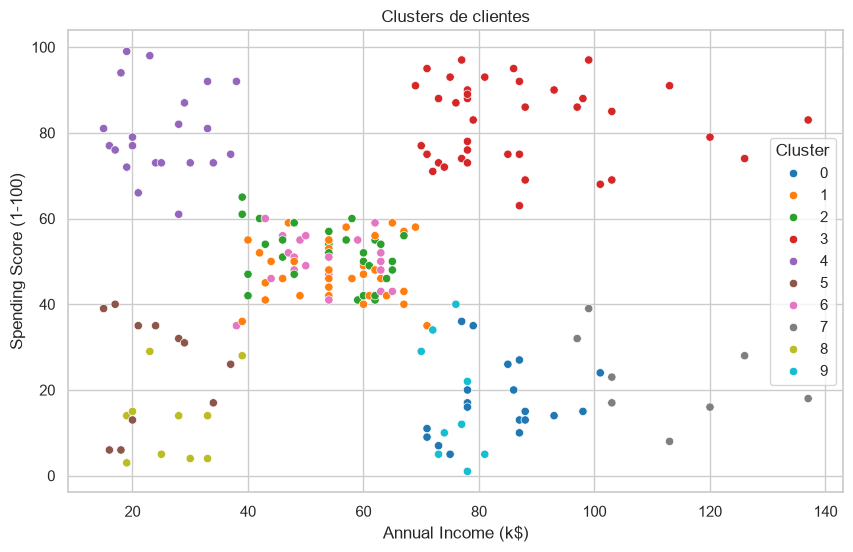

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette=sns.color_palette("tab10", 10))
plt.title('Clusters de clientes')
plt.show()

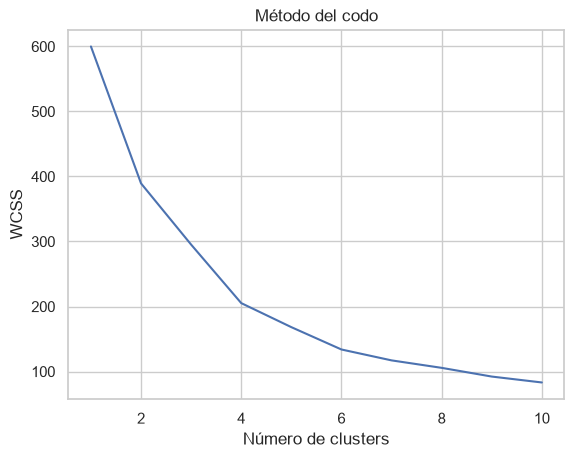

In [69]:
# Función para calcular la Suma de Cuadrados Dentro del Cluster (WCSS)
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=25)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes números de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el método del codo
plt.plot(range(1, 11), wcss)
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

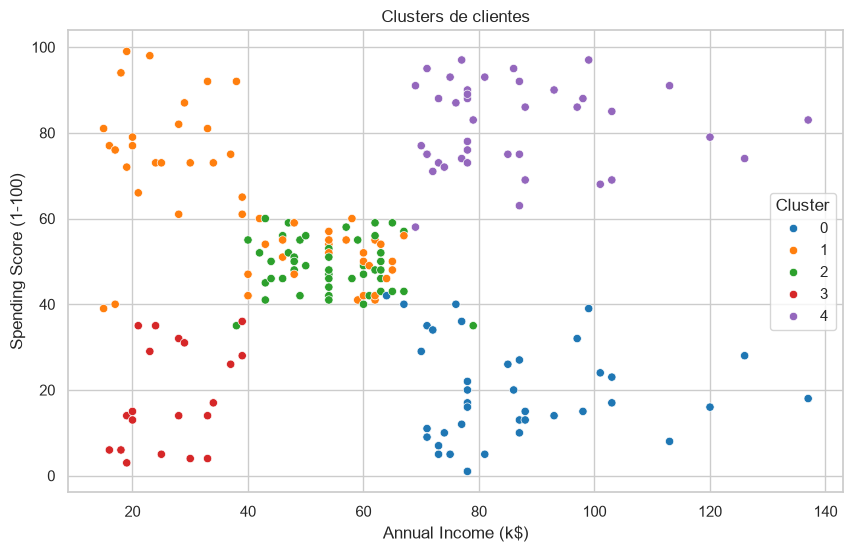

In [70]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=25)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters

# mostrar gráfica
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette=sns.color_palette("tab10", 5))
plt.title('Clusters de clientes')
plt.show()

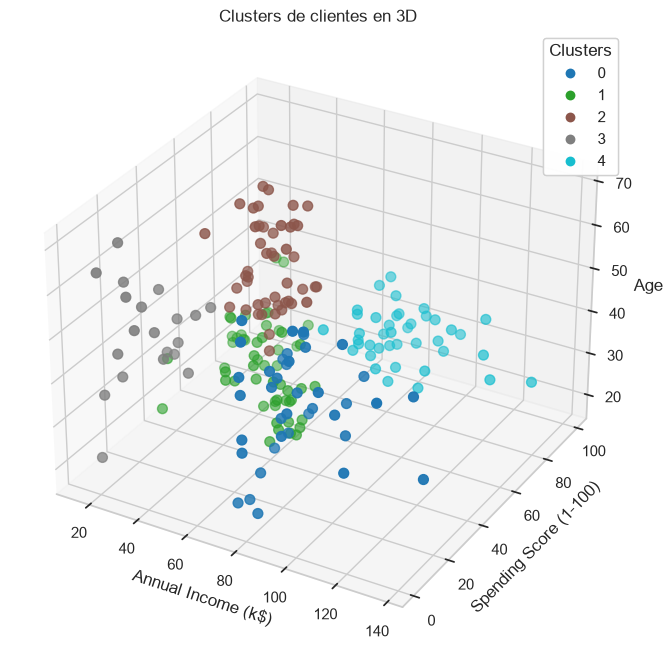

In [71]:
from mpl_toolkits.mplot3d import Axes3D

# Configurar el estilo de Seaborn
sns.set(style="whitegrid")

# Crear una figura en 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Gráfico 3D de dispersión
scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'],
                     c=df['Cluster'], cmap="tab10", s=50)

# Etiquetas de los ejes
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')

# Título de la gráfica
ax.set_title('Clusters de clientes en 3D')

# Añadir la leyenda
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

# Mostrar la gráfica
plt.show()

In [72]:
cluster_analysis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,39.871795,86.102564,19.358974
1,25.185185,41.092593,62.240741
2,55.638298,54.382979,48.851064
3,46.250000,26.750000,18.350000
4,32.875000,86.100000,81.525000


In [73]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad media: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual medio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificación RetailMax: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===========================================")

Cluster 0:
 - Edad media: 39.87
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 19.36
Cluster 1:
 - Edad media: 25.19
 - Ingreso anual medio: 41.09k$
 - Calificación RetailMax: 62.24
Cluster 2:
 - Edad media: 55.64
 - Ingreso anual medio: 54.38k$
 - Calificación RetailMax: 48.85
Cluster 3:
 - Edad media: 46.25
 - Ingreso anual medio: 26.75k$
 - Calificación RetailMax: 18.35
Cluster 4:
 - Edad media: 32.88
 - Ingreso anual medio: 86.10k$
 - Calificación RetailMax: 81.53


In [74]:
# Convertir a numérica
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# selección de features
extended_features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# estandarización
scaled_extended_features = scaler.fit_transform(extended_features)

# Aplicar K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=23)
clusters_extended = kmeans.fit_predict(scaled_extended_features)

# Sustituir clusters anteriores
df['Cluster'] = clusters_extended

# análisis
extended_cluster_analysis = df[['Gender','Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
extended_cluster_analysis

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,1.000000,48.720930,46.186047,39.674419
1,0.451613,40.419355,90.000000,15.741935
2,0.000000,28.250000,62.000000,71.675000
3,0.000000,55.903226,48.774194,38.806452
4,1.000000,28.345455,60.800000,68.654545


In [81]:
for cluster in extended_cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {extended_cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {extended_cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Calificación RetailMax promedio: {extended_cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print(f" - % mujeres: {extended_cluster_analysis['Gender'][cluster]:.2%}")
    print("================================")

Cluster 0:
 - Edad promedio: 48.72
 - Ingreso anual promedio: 46.19k$
 - Calificación RetailMax promedio: 39.67
 - % mujeres: 100.00%
Cluster 1:
 - Edad promedio: 40.42
 - Ingreso anual promedio: 90.00k$
 - Calificación RetailMax promedio: 15.74
 - % mujeres: 45.16%
Cluster 2:
 - Edad promedio: 28.25
 - Ingreso anual promedio: 62.00k$
 - Calificación RetailMax promedio: 71.67
 - % mujeres: 0.00%
Cluster 3:
 - Edad promedio: 55.90
 - Ingreso anual promedio: 48.77k$
 - Calificación RetailMax promedio: 38.81
 - % mujeres: 0.00%
Cluster 4:
 - Edad promedio: 28.35
 - Ingreso anual promedio: 60.80k$
 - Calificación RetailMax promedio: 68.65
 - % mujeres: 100.00%
